In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm

In [2]:
width=4
gap = 2
num_iters = 50

resize_wid=1024
rw_div2 = int(resize_wid/2)

inner_wid=100
indiv2 = int(inner_wid/2)

In [3]:
import jax as jx

In [4]:
def sig_val_thresholding(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)): ##Sigma[Sigma < thresh] = 0
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    S_reduced = np.array(arr)
    return(U, S_reduced, Vh)

def sig_val_thresholding_fast(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    thresh = Sigma.max() * zero_thresh
    S_reduced = np.where(Sigma > thresh, Sigma, 0)
    return U, S_reduced, Vh

def sig_val_thresholding_jax(data, zero_thresh):
    U, Sigma, Vh = jx.numpy.linalg.svd(data, full_matrices=False)
    print(len(Sigma))
    thresh = Sigma.max() * zero_thresh
    S_reduced = np.where(Sigma > thresh, Sigma, 0)
    return U, S_reduced, Vh

In [5]:
zte_radial_kspacedlt, zte_radial_coordsdlt, zte_radial_kspacezero, zte_radial_coordszero, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=(gap), undersampling_factor=1)


cartesian_zte = asm.nufft_gridding(kspace=zte_radial_kspacezero, coords=zte_radial_coordszero)

cartesian_kspace_enl = asm.zero_padding(cart_kspace=cartesian_zte, resize_x=resize_wid, resize_y=resize_wid)

inner_region, inner_mask, start, end = asm.inner_portion(enlarged_kspace=cartesian_kspace_enl, inner_sidelen=inner_wid)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


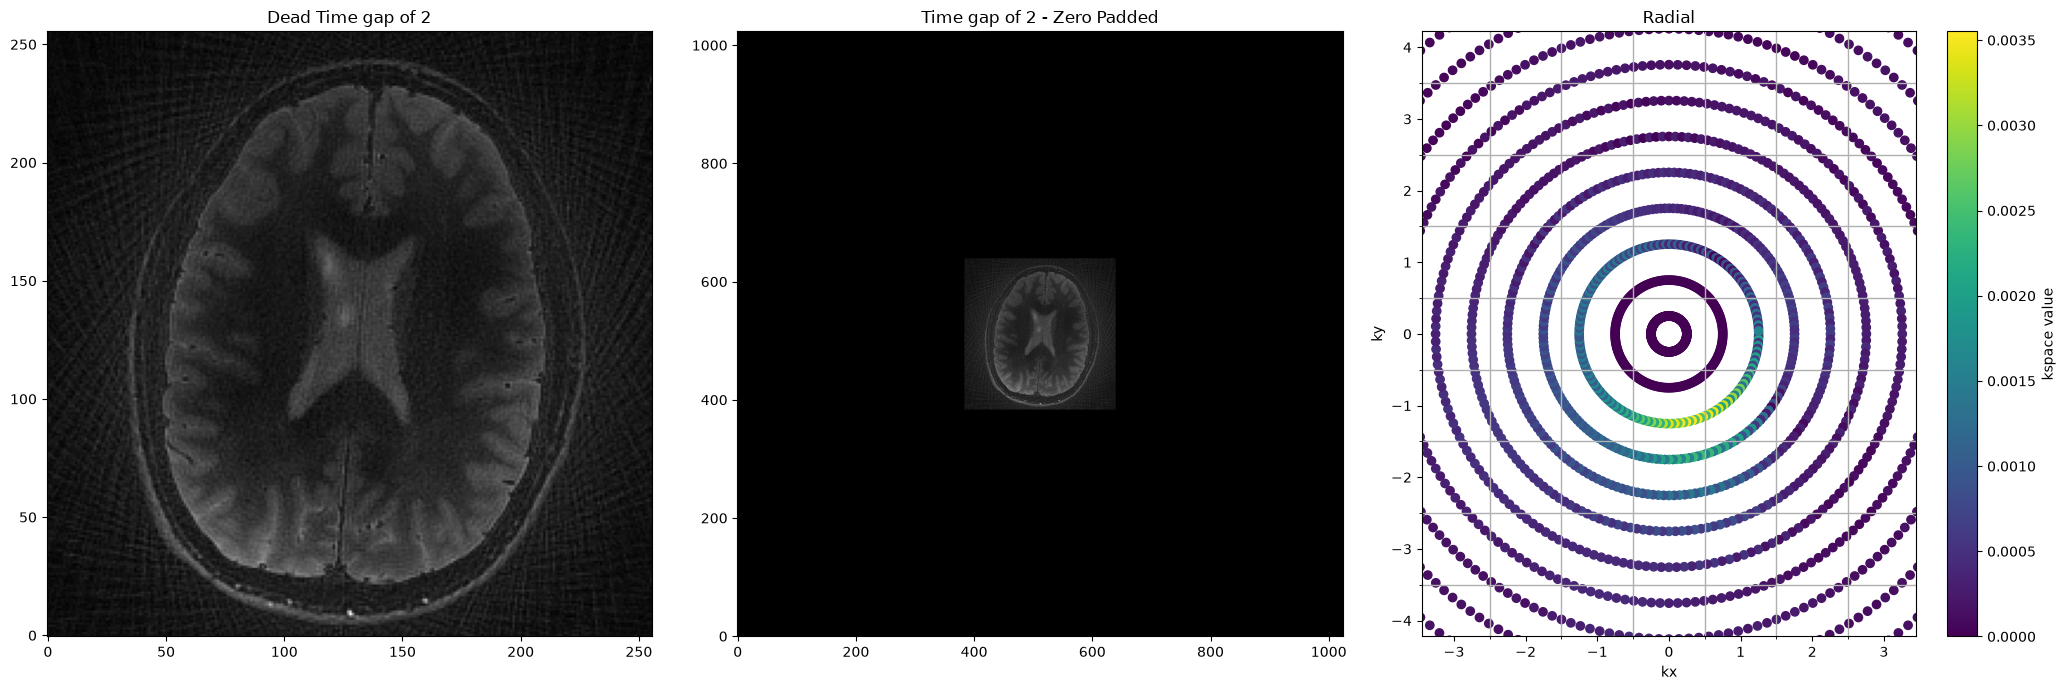

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(21, 7))

im_grid1 = sp.ifft(cartesian_zte, axes=(-2, -1))
im_1 = np.sum(np.abs(im_grid1)**2, axis=0)**0.5
ax[0].imshow(im_1, cmap='gray', origin='lower')
ax[0].set_title(f'Dead Time gap of {gap}')

im_grid2 = sp.ifft(cartesian_kspace_enl, axes=(-2, -1))
im_2 = np.sum(np.abs(im_grid2)**2, axis=0)**0.5
ax[1].imshow(im_2, cmap='gray', origin='lower')
ax[1].set_title(f'Time gap of {gap} - Zero Padded')


zte_radial_coordszero = zte_radial_coordszero.reshape(-1, 2)

im2 = ax[2].scatter(zte_radial_coordszero[:, 0],zte_radial_coordszero[:, 1], c=np.abs(zte_radial_kspacezero[0]), cmap='viridis')
fig.colorbar(im2, ax=ax[2], label='kspace value')
ax[2].set_title('Radial')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].grid(visible=True, which='minor', linewidth=1)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].set_xlim(0 - 3, 0 + 3)
ax[2].set_ylim(0 - 3, 0 + 3)

plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


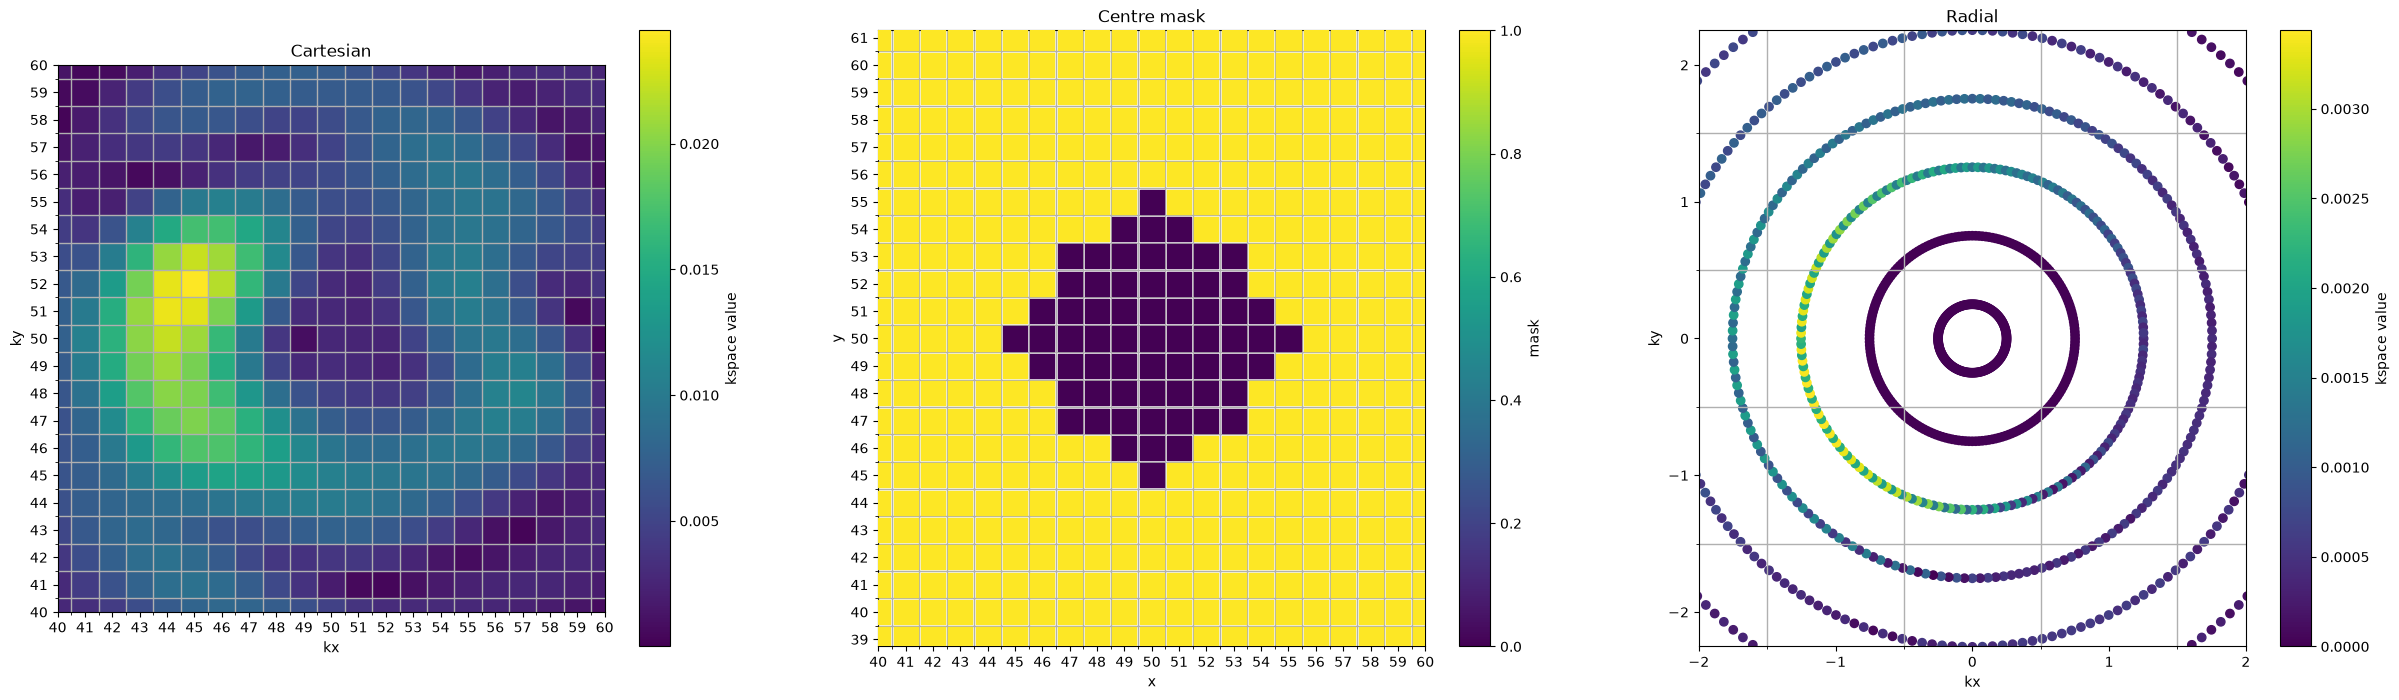

In [7]:
cy, cx = inner_wid // 2, inner_wid // 2
r = 4  # radius in pixels; adjust to cover the gap
yy, xx = np.ogrid[:inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

mask[(cx-5):(cx+6), cy] = False
mask[(cx), (cy-5):(cy+6)] = False


masked_inner = inner_region.copy()
masked_inner[:,~mask] = 0

inner_removed = inner_region.copy()
inner_removed[:,mask] = 0

totalwid = 1024
totaldiv = totalwid // 2

mask2 = np.ones((totalwid, totalwid), dtype=bool)

mask2[(indiv2-3):(indiv2+3), indiv2:indiv2+1] = False
mask2[(indiv2), (indiv2-2):(indiv2+3)] = False


asm.plot_mask(inner_region, mask=mask, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)

In [8]:
def LORAKS_loop_hard(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask):
    ksp_forhankel = cartesian_inputkspace.copy()
    deltas = []
    k_prev = None
    iter_count = 0
    while iter_count < n_iters:
        hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=window_size)
        U, S_reduced, Vh = asm.sig_val_thresholding_jax(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh
        kspace_cart_coils_recon = asm.hankel_H_averaged(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
        kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

        for coil in range(ksp_forhankel.shape[0]):
            kspace_cart_coils_consistent[coil, dtg_mask] = cartesian_inputkspace[coil, dtg_mask]
        ksp_forhankel = kspace_cart_coils_consistent.copy()

        vec = ksp_forhankel[:, ~mask]

        if k_prev is not None:
            deltas.append(np.linalg.norm(vec - k_prev) / np.linalg.norm(k_prev))
        k_prev = vec.copy()

        iter_count += 1

    output_kspace = ksp_forhankel.copy()
    return output_kspace, deltas


def LORAKS_loop_soft(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask):
    ksp_forhankel = cartesian_inputkspace.copy()
    deltas = []
    k_prev = None
    iter_count = 0
    while iter_count < n_iters:
        hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=window_size)
        U, S_reduced, Vh = asm.sig_val_thresholding_jax_soft(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh
        
        kspace_cart_coils_recon = asm.hankel_H_averaged(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
        kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

        for coil in range(ksp_forhankel.shape[0]):
            kspace_cart_coils_consistent[coil, dtg_mask] = cartesian_inputkspace[coil, dtg_mask]
        ksp_forhankel = kspace_cart_coils_consistent.copy()

        vec = ksp_forhankel[:, ~mask]

        if k_prev is not None:
            deltas.append(np.linalg.norm(vec - k_prev) / np.linalg.norm(k_prev))
        k_prev = vec.copy()

        iter_count += 1

    output_kspace = ksp_forhankel.copy()
    return output_kspace, deltas

In [9]:
output_kspace_fiv, delta_fiv = LORAKS_loop_hard(n_iters=50, window_size=5, zero_thresh=0.2, cartesian_inputkspace=inner_region, dtg_mask=mask)
recombined_fiv = asm.jigsaw(output_kspace=output_kspace_fiv, isolation_mask = inner_mask, start=start, end=end, enlarged_kspace=cartesian_kspace_enl)
cartesian_kspace_rebuild_fiv = asm.zero_padding(recombined_fiv, 256,256)
post_loop_kspace_fiv = output_kspace_fiv.copy()

output_kspace_soft, delta_soft = LORAKS_loop_soft(n_iters=50, window_size=5, zero_thresh=0.005, cartesian_inputkspace=inner_region, dtg_mask=mask)
recombined_soft = asm.jigsaw(output_kspace=output_kspace_soft, isolation_mask = inner_mask, start=start, end=end, enlarged_kspace=cartesian_kspace_enl)
cartesian_kspace_rebuild_soft = asm.zero_padding(recombined_soft, 256,256)
post_loop_kspace_soft = output_kspace_soft.copy()

## Storing the inner kspace values to visualise convergence

1. At each iteration take the array and flatten
2. Take the square root of the sum of all the squared values and store
3. For each iteration, calculate the relative change by subtracting k from k-1 then dividing by k-1

Note:
1. Likely quicker to prebuild the df
2. Likely quicker to calculate

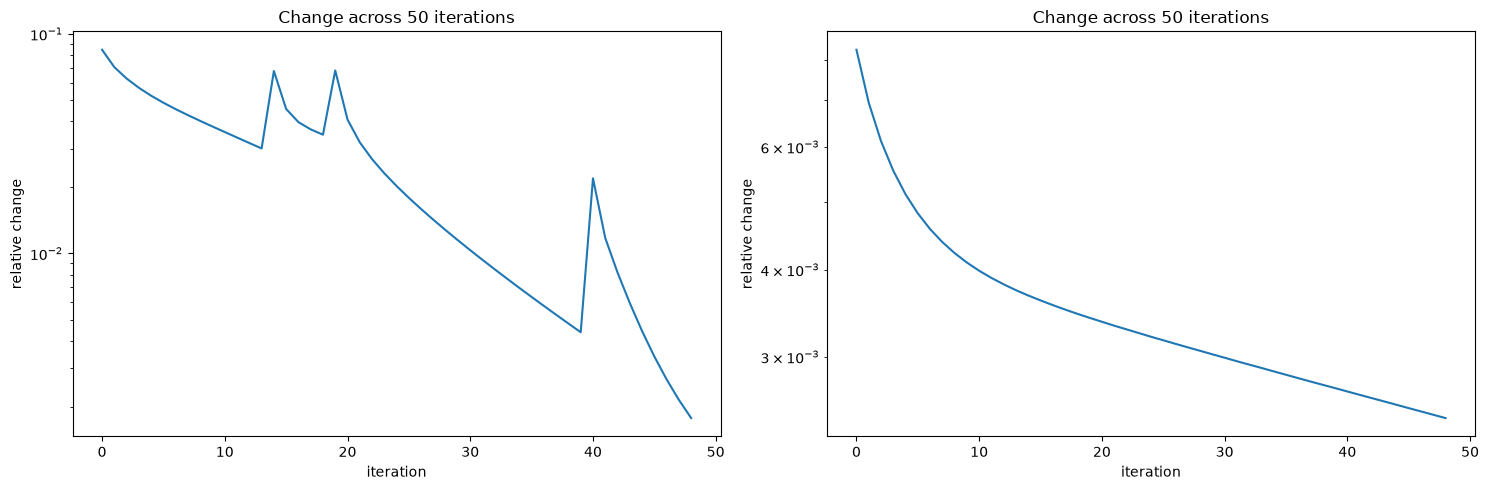

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].semilogy(delta_fiv)
axes[0].set_title(f'Change across {num_iters} iterations')
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("relative change")

axes[1].semilogy(delta_soft)
axes[1].set_title(f'Change across {num_iters} iterations')
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("relative change")

plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


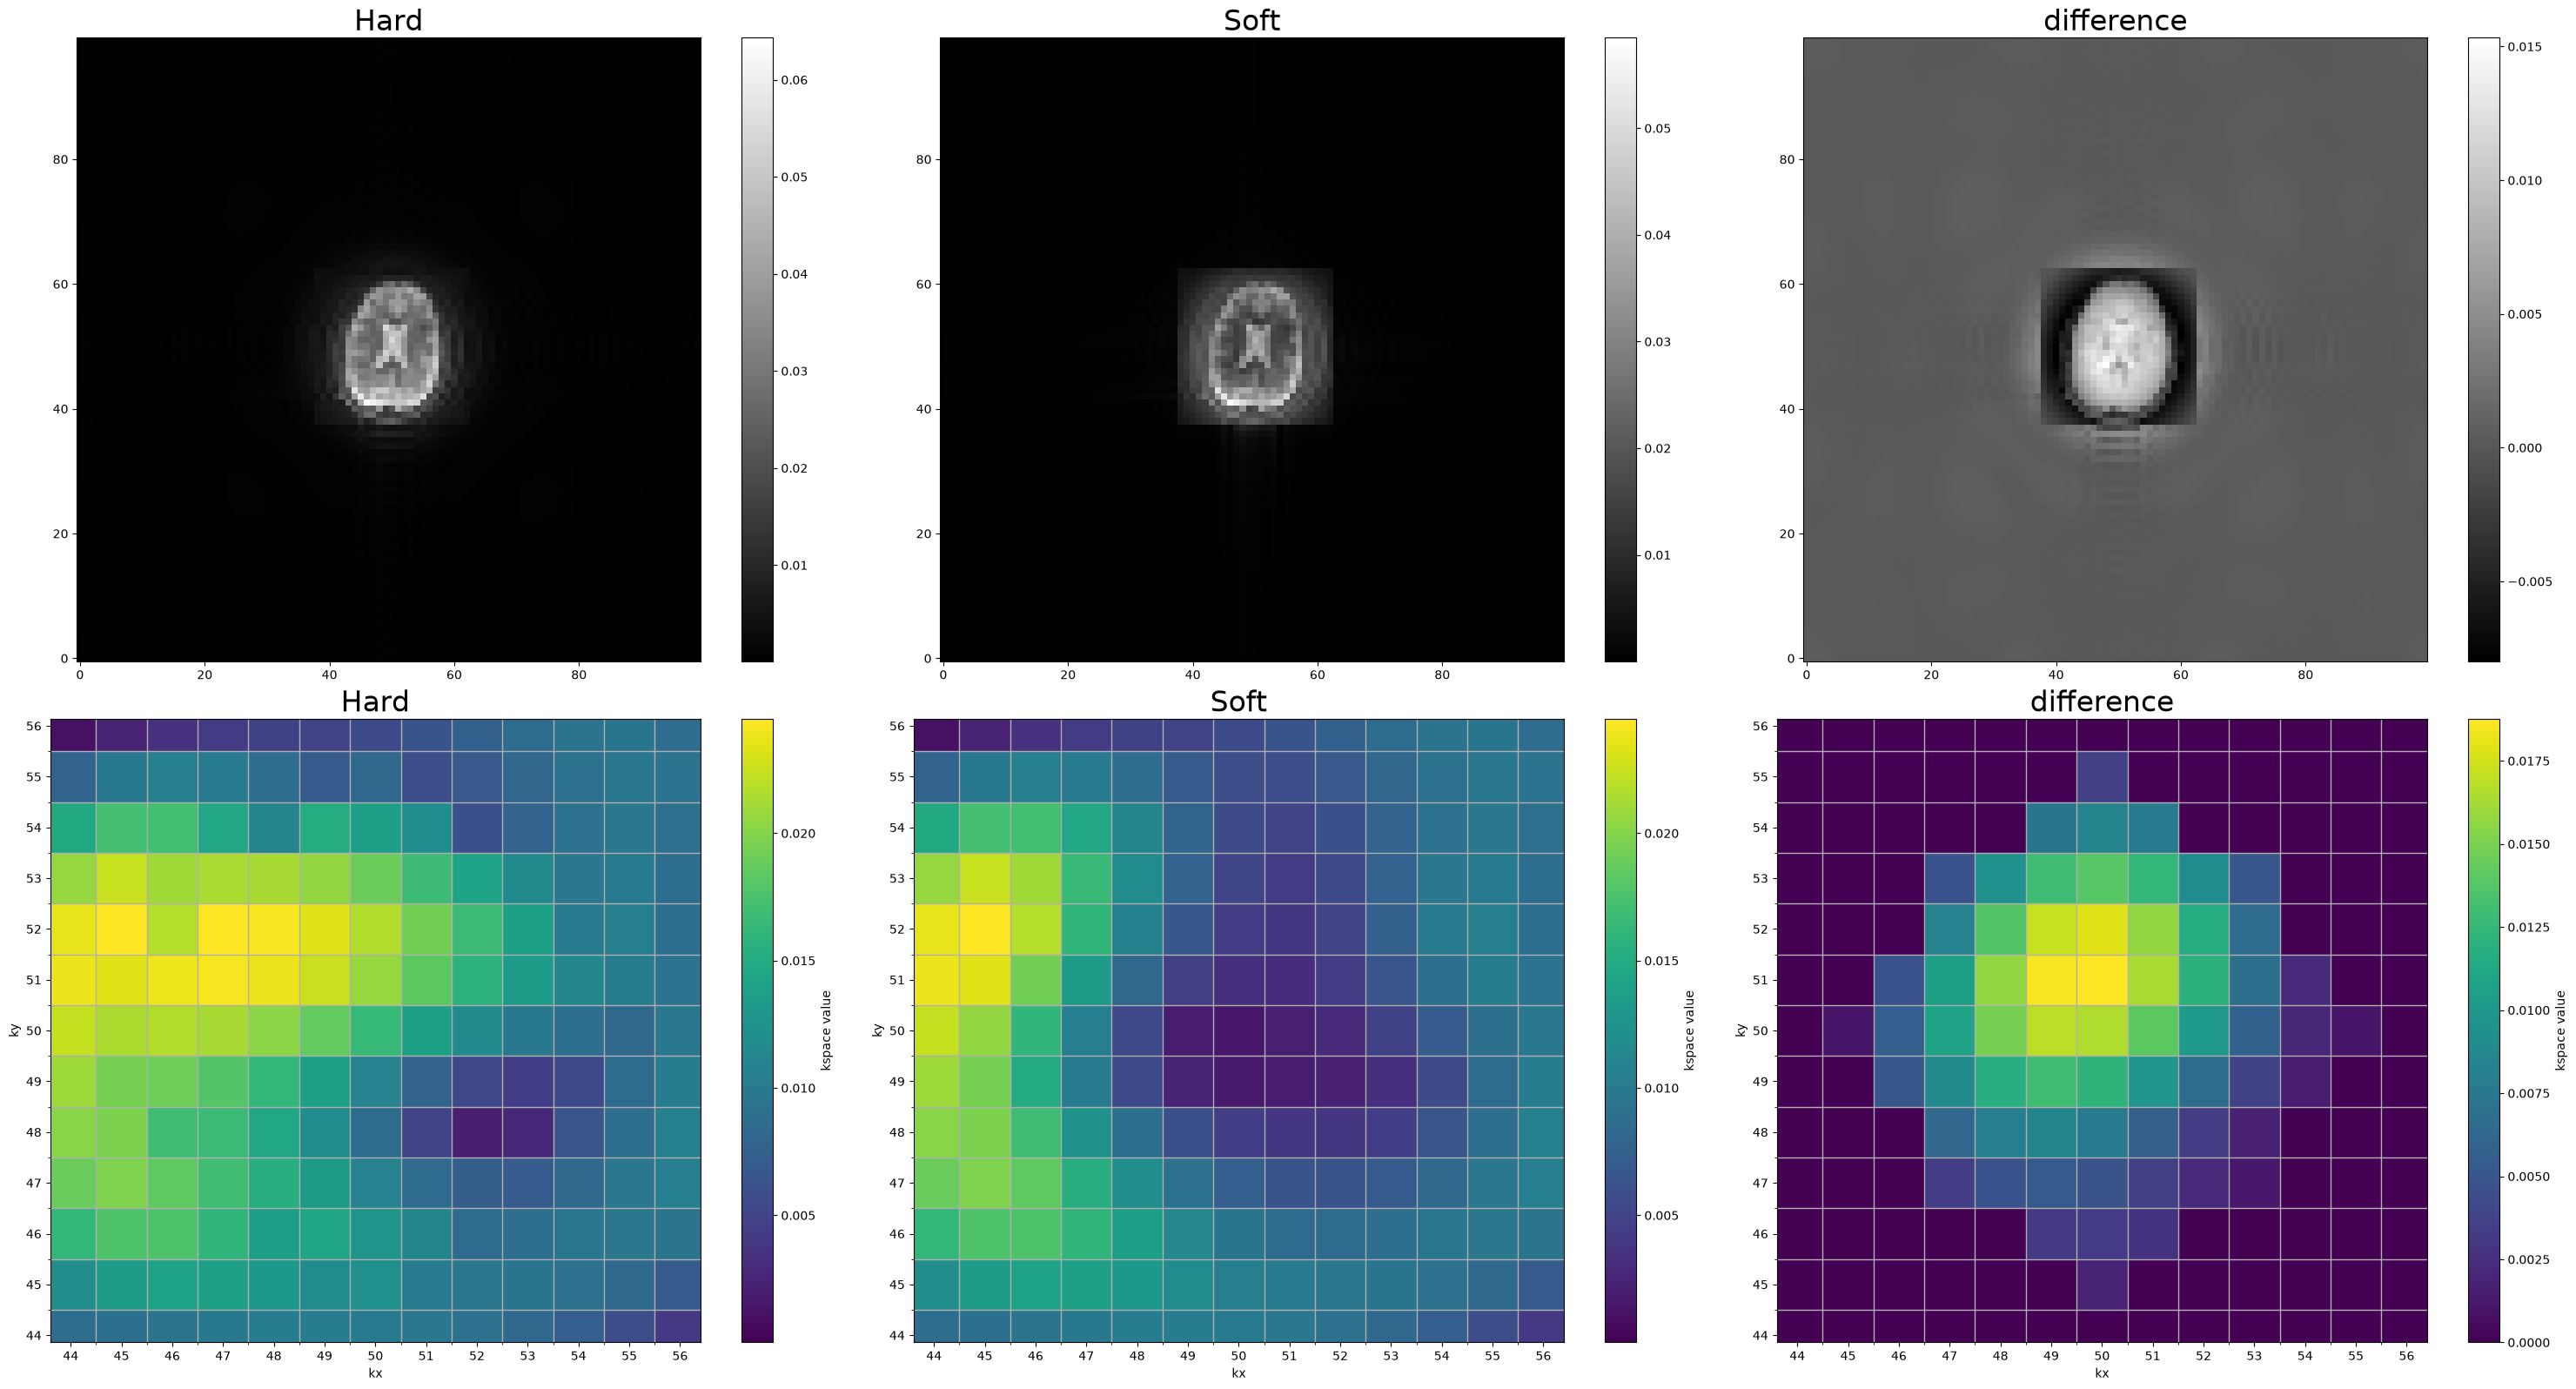

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(30, 16))


im1 = np.sum(np.abs(sp.ifft(post_loop_kspace_fiv))**2, axis=0)**0.5
p1 = ax[0, 0].imshow(im1, cmap='gray', origin='lower')
ax[0, 0].set_title(f'Hard', fontsize=24)
fig.colorbar(p1, ax=ax[0, 0])


im2_soft = np.sum(np.abs(sp.ifft(post_loop_kspace_soft))**2, axis=0)**0.5
p1_soft = ax[0, 1].imshow(im2_soft, cmap='gray', origin='lower')
ax[0, 1].set_title(f'Soft', fontsize=24)
fig.colorbar(p1_soft, ax=ax[0, 1])


p2 = ax[0, 2].imshow(im1-im2_soft, cmap='gray', origin='lower')
ax[0, 2].set_title('difference', fontsize=24)
fig.colorbar(p2, ax=ax[0, 2])

# Row 1: k-space
all_coords = zte_radial_coordsdlt.reshape(-1, 2)

im1k = ax[1, 0].imshow(np.abs(post_loop_kspace_fiv[0]), cmap='viridis', origin='lower')
fig.colorbar(im1k, ax=ax[1, 0], label='kspace value')
ax[1, 0].set_title(f'Hard', fontsize=24)
ax[1, 0].set_xlabel('kx')
ax[1, 0].set_ylabel('ky')
ax[1, 0].axis('equal')
ax[1, 0].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 0].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].grid(visible=True, which='minor', linewidth=1)
ax[1, 0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 0].yaxis.set_major_locator(plt.MultipleLocator(1))


im1k_soft = ax[1, 1].imshow(np.abs(post_loop_kspace_soft[0]), cmap='viridis', origin='lower')
fig.colorbar(im1k_soft, ax=ax[1, 1], label='kspace value')
ax[1, 1].set_title(f'Soft', fontsize=24)
ax[1, 1].set_xlabel('kx')
ax[1, 1].set_ylabel('ky')
ax[1, 1].axis('equal')
ax[1, 1].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 1].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].grid(visible=True, which='minor', linewidth=1)
ax[1, 1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 1].yaxis.set_major_locator(plt.MultipleLocator(1))


diff = post_loop_kspace_fiv - post_loop_kspace_soft

im2k = ax[1, 2].imshow(np.abs(diff[0]), cmap='viridis', origin='lower')
fig.colorbar(im2k, ax=ax[1, 2], label='kspace value')
ax[1, 2].set_title('difference', fontsize=24)
ax[1, 2].set_xlabel('kx')
ax[1, 2].set_ylabel('ky')
ax[1, 2].axis('equal')
ax[1, 2].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 2].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].grid(visible=True, which='minor', linewidth=1)
ax[1, 2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 2].yaxis.set_major_locator(plt.MultipleLocator(1))

plt.tight_layout()
plt.show()

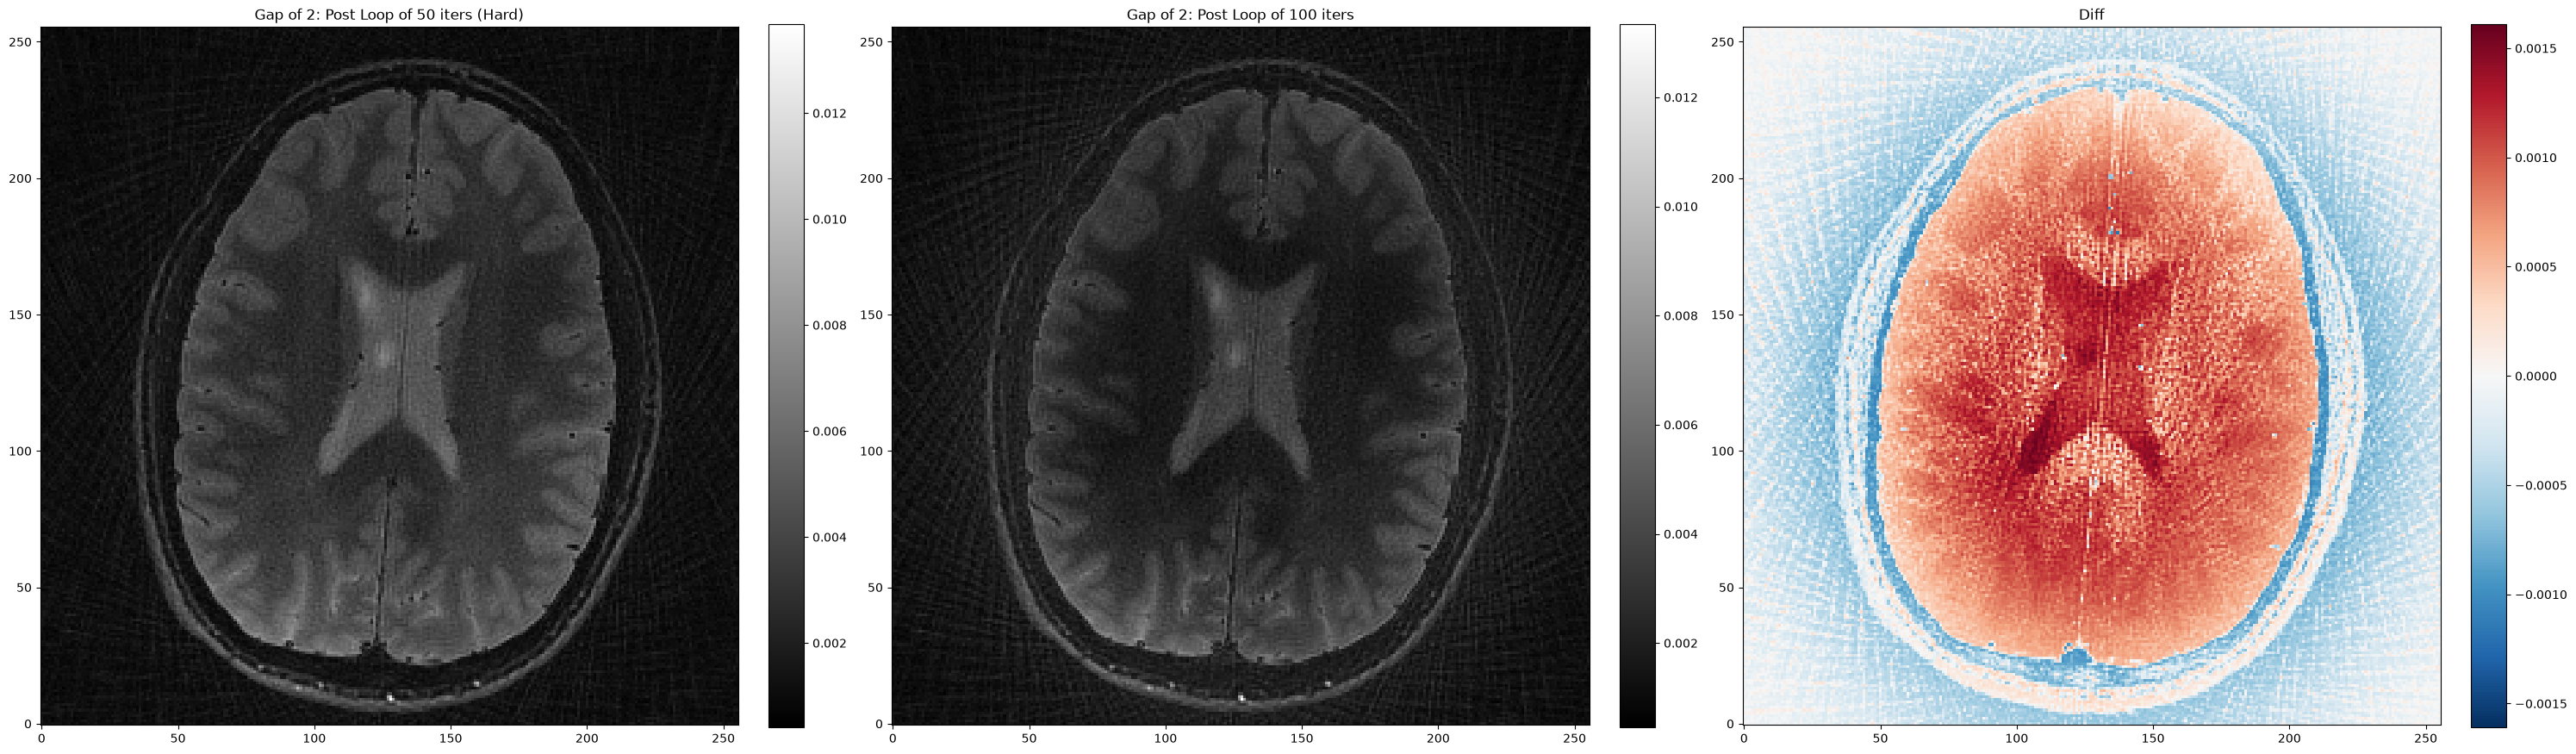

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 16))

im_grid2 = sp.ifft(cartesian_kspace_rebuild_fiv, axes=(-2, -1))
im_2 = np.sum(np.abs(im_grid2)**2, axis=0)**0.5
p1 = ax[0].imshow(im_2, cmap='gray', origin='lower')
ax[0].set_title(f'Gap of 2: Post Loop of {num_iters} iters (Hard)')
fig.colorbar(p1, ax=ax[0], fraction=0.046, pad=0.04)

im_grid2_soft = sp.ifft(cartesian_kspace_rebuild_soft, axes=(-2, -1))
im_2_soft = np.sum(np.abs(im_grid2_soft)**2, axis=0)**0.5
p1_soft = ax[1].imshow(im_2_soft, cmap='gray', origin='lower')
ax[1].set_title(f'Gap of 2: Post Loop of {100} iters')
fig.colorbar(p1_soft, ax=ax[1], fraction=0.046, pad=0.04)

diff = im_2 - im_2_soft
vmax = np.abs(diff).max()
p2 = ax[2].imshow(diff, cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
ax[2].set_title('Diff')
fig.colorbar(p2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()